In [1]:
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import matplotlib.pyplot as plt

In [80]:

colunas=80
linhas=10

In [102]:

ativos = [a for a in range(colunas)]
retornos = np.random.default_rng().uniform(0.0355,0.1455, size=(linhas,len(ativos)))

In [103]:
retornos

array([[0.13273762, 0.10594278, 0.1165294 , 0.13866603, 0.1279189 ,
        0.05147089, 0.13423204, 0.08190361, 0.04464619, 0.14519854,
        0.13261359, 0.09408501, 0.1097425 , 0.09694406, 0.07814325,
        0.06036019, 0.04041291, 0.09958657, 0.12722888, 0.05632618,
        0.09499262, 0.08509622, 0.14330153, 0.11815511, 0.10022371,
        0.07884824, 0.06133777, 0.14501112, 0.08096211, 0.12008743,
        0.0447535 , 0.09633161, 0.10428228, 0.14526369, 0.03582438,
        0.13572435, 0.04369469, 0.05596216, 0.13617356, 0.06384816,
        0.05756149, 0.04480712, 0.13445166, 0.14322969, 0.07783529,
        0.08007866, 0.04287038, 0.08109002, 0.11354955, 0.0499109 ,
        0.14450009, 0.11086339, 0.04993335, 0.06215519, 0.09673652,
        0.13776775, 0.08739492, 0.14503457, 0.03970271, 0.08547139,
        0.0858183 , 0.05345557, 0.14200684, 0.07676177, 0.12479898,
        0.05962583, 0.12936975, 0.08935839, 0.12745124, 0.10847857,
        0.05510407, 0.13568894, 0.06275294, 0.03

In [104]:

df = pd.DataFrame(retornos, index=range(linhas), columns=ativos)
df = df.pct_change().dropna().reset_index(drop=True)
# df = df.dropna().reset_index(drop=True)
df

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
0,-0.075236,-0.538845,-0.095019,-0.365232,-0.087328,0.122715,-0.479079,0.081171,0.093234,-0.727386,...,-0.128076,-0.605241,0.581740,1.171449,0.500948,-0.066641,0.653879,-0.574080,0.453307,-0.015281
1,-0.174752,0.400327,0.104651,0.447484,-0.196809,0.580449,-0.407571,0.329973,1.240330,2.300190,...,0.073561,0.492215,0.427113,-0.449927,0.365549,-0.636436,0.171430,0.256171,-0.480215,-0.324877
2,0.090449,0.169366,-0.164729,-0.110243,-0.254168,0.583404,0.557493,-0.614951,-0.577172,-0.187225,...,-0.037307,-0.297235,-0.222693,-0.013177,0.118520,1.083942,-0.314717,0.568574,0.061500,-0.059893
3,0.196909,0.025464,0.025023,-0.068023,0.390531,-0.004965,1.069382,0.542044,1.741578,-0.427578,...,-0.079261,0.945276,0.058220,-0.011878,-0.021935,-0.567423,0.540955,-0.017403,0.407752,0.709074
4,-0.426732,0.233018,-0.518969,-0.492330,-0.123732,-0.478049,-0.317311,-0.471114,-0.639611,1.001539,...,1.184966,-0.537750,-0.184207,1.711787,-0.373949,1.889314,0.113989,-0.493606,0.392343,0.194822
5,-0.071872,-0.147186,-0.218441,0.947820,0.470432,0.699128,0.405704,0.479352,0.602616,-0.344945,...,-0.146575,1.507322,-0.178921,-0.599874,-0.251353,0.209139,-0.678350,1.228624,-0.171845,-0.601514
6,0.407160,0.187145,1.309857,-0.426409,-0.356714,-0.502050,-0.399065,1.397094,0.418840,0.797222,...,0.536624,-0.309226,0.535194,1.168005,0.625511,-0.253293,1.133124,-0.092798,-0.297100,0.190057
7,0.270577,-0.299511,-0.498565,0.153721,0.236847,1.027704,0.128248,-0.222180,0.245605,-0.718768,...,-0.398741,-0.429966,0.126242,-0.091563,-0.092583,0.200719,0.449547,0.107237,0.074103,0.750008
8,-0.550506,-0.345359,1.652186,0.892792,0.370050,-0.415664,0.172249,-0.232879,-0.524491,1.796212,...,-0.169102,1.690650,-0.261740,0.341545,0.319940,-0.274134,-0.305581,-0.432514,-0.129351,-0.351447


In [105]:
model = pyo.ConcreteModel()

df_mean = df.mean()
df_cov = df.cov()

model.ativos = pyo.Set(initialize=ativos)
model.range_ativos = pyo.RangeSet(0, len(ativos)-1)
model.periodos = pyo.Set(initialize=range(linhas-1))
model.retornos = pyo.Param(model.range_ativos, initialize=lambda model,a: df_mean.iloc[a])
model.sigma = pyo.Param(model.range_ativos, model.range_ativos, initialize=lambda model,a,b: df_cov.iloc[a,b])
# model.x = pyo.Var(model.range_ativos, domain=pyo.NonNegativeReals)
model.y=pyo.Var(model.range_ativos, domain=pyo.Binary)
#linear sharpe
model.z = pyo.Var(model.range_ativos,domain=pyo.NonNegativeReals)
model.k = pyo.Var(domain=pyo.NonNegativeReals)
model.w = pyo.Var(model.range_ativos, domain=pyo.NonNegativeReals)
model.K_MAX = pyo.Param(initialize=100)
model.VALOR_PMIN = pyo.Param(initialize=0.05)
model.VALOR_PMAX = pyo.Param(initialize=0.20)

#Restrições do sharpe
def res_z(model):
    return sum(model.z[a] for a in model.range_ativos) == model.k    # z=kx
model.res_res_z = pyo.Constraint(rule=res_z)

def res_k(model):
    return sum(model.retornos[a] * model.z[a] for a in model.range_ativos) == 1  
model.res_res_k = pyo.Constraint(rule=res_k)

def obj_rule(model):
    var = sum(model.sigma[a,b] * model.z[a] * model.z[b] for a in model.range_ativos for b in model.range_ativos)
    return var
model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

# Restricao peso min
def r_peso_min(model,a):
    return model.w[a] <= model.K_MAX * model.y[a]
model.peso_min = pyo.Constraint(model.range_ativos,rule=r_peso_min)

def r_peso_min_2(model,a):
    return model.w[a] <= model.k
model.peso_min_2 = pyo.Constraint(model.range_ativos, rule=r_peso_min_2)

def r_peso_min_final(model,a):
    return model.w[a] >= model.k-model.K_MAX*(1-model.y[a])
model.peso_min_final = pyo.Constraint(model.range_ativos, rule=r_peso_min_final)

def pm(model,a):
    return model.z[a] >= model.VALOR_PMIN*model.w[a]
model.r_pm = pyo.Constraint(model.range_ativos, rule=pm)

def teto_sem_selecao(model, a):
    return model.z[a] <= model.VALOR_PMAX * model.w[a]
model.teto_sem_selecao = pyo.Constraint(model.range_ativos, rule=teto_sem_selecao)

# restrição cardinalidade
def res_min_ativos(model):
    return sum(model.y[a] for a in model.range_ativos) >= 10
model.res_min_ativoss = pyo.Constraint( rule=res_min_ativos)
def res_max_ativos(model):
    return sum(model.y[a] for a in model.range_ativos) <= 10
model.res_max_ativoss = pyo.Constraint( rule=res_max_ativos)

In [106]:

# ------------------- solver
opt = SolverFactory('cplex_direct')
opt.options['timelimit']=60
res = opt.solve(model,tee=True)

Version identifier: 22.2.0.0 | 2026-07-01 | 7cae668b4
CPXPARAM_Read_DataCheck                          1
CPXPARAM_TimeLimit                               60
Tried aggregator 1 time.
MIQP Presolve eliminated 1 rows and 0 columns.
MIQP Presolve modified 80 coefficients.
Reduced MIQP has 403 rows, 241 columns, and 1120 nonzeros.
Reduced MIQP has 80 binaries, 0 generals, 0 SOSs, and 0 indicators.
Reduced MIQP objective Q matrix has 6400 nonzeros.
Presolve time = 0.00 sec. (1.79 ticks)
Probing fixed 0 vars, tightened 1 bounds.
Probing time = 0.00 sec. (0.62 ticks)
Cover probing fixed 0 vars, tightened 18 bounds.
Tried aggregator 1 time.
Reduced MIQP has 403 rows, 241 columns, and 1120 nonzeros.
Reduced MIQP has 80 binaries, 0 generals, 0 SOSs, and 0 indicators.
Reduced MIQP objective Q matrix has 6400 nonzeros.
Presolve time = 0.00 sec. (1.23 ticks)
Classifier predicts products in MIQP should not be linearized.
Represolve...

Tried aggregator 1 time.
MIQP Presolve eliminated 1 rows and 0 co

In [107]:
print(pyo.value(model.k))
for a in model.ativos:
    # print(f'Ativo {a}: Z:{model.z[a].value:.4f};K:{model.k.value}; X=Z/K: {(model.z[a].value/model.k.value):.4f}; y={model.y[a].value:.4f}')
    print(f'Ativo {a}: Z:{model.z[a].value:.4f};K:{model.k.value}; X=Z/K: {(model.z[a].value/model.k.value):.4f}')

4.939800700627647
Ativo 0: Z:0.2672;K:4.939800700627647; X=Z/K: 0.0541
Ativo 1: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 2: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 3: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 4: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 5: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 6: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 7: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 8: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 9: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 10: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 11: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 12: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 13: Z:0.2862;K:4.939800700627647; X=Z/K: 0.0579
Ativo 14: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 15: Z:0.2470;K:4.939800700627647; X=Z/K: 0.0500
Ativo 16: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 17: Z:0.0000;K:4.939800700627647; X=Z/K: 0.0000
Ativo 18: Z:0.0000;K

In [108]:
y_selec = {a: np.round((model.z[a].value)/model.k.value, 4) for a in model.range_ativos if (model.z[a].value)/model.k.value > 0}
final  = {z:x for z,x in y_selec.items() if x > 0.0}
final

{0: np.float64(0.0541),
 13: np.float64(0.0579),
 15: np.float64(0.05),
 20: np.float64(0.1014),
 26: np.float64(0.1702),
 32: np.float64(0.0722),
 34: np.float64(0.1522),
 36: np.float64(0.0593),
 45: np.float64(0.1753),
 47: np.float64(0.1075)}

In [109]:
print("Total de ativos: ",len(final))
print(f"Total de x: {sum(final.values())}")

Total de ativos:  10
Total de x: 1.0001


In [110]:
ativos_escolhidos = list(final.keys())
pesos = list(final.values())
df_f = df[ativos_escolhidos]*pesos
df_f2 = df_f.sum(axis=1)
c_otm = df_f2+1
c_otm2 = c_otm.cumprod()*100


In [111]:
c_otm

0    1.202452
1    1.202409
2    1.202499
3    1.202501
4    1.202404
5    1.202484
6    1.202475
7    1.202459
8    1.202439
dtype: float64

In [113]:
c_otm2

0    120.245250
1    144.584003
2    173.862189
3    209.069464
4    251.386006
5    302.287643
6    363.493353
7    437.085704
8    525.568846
dtype: float64

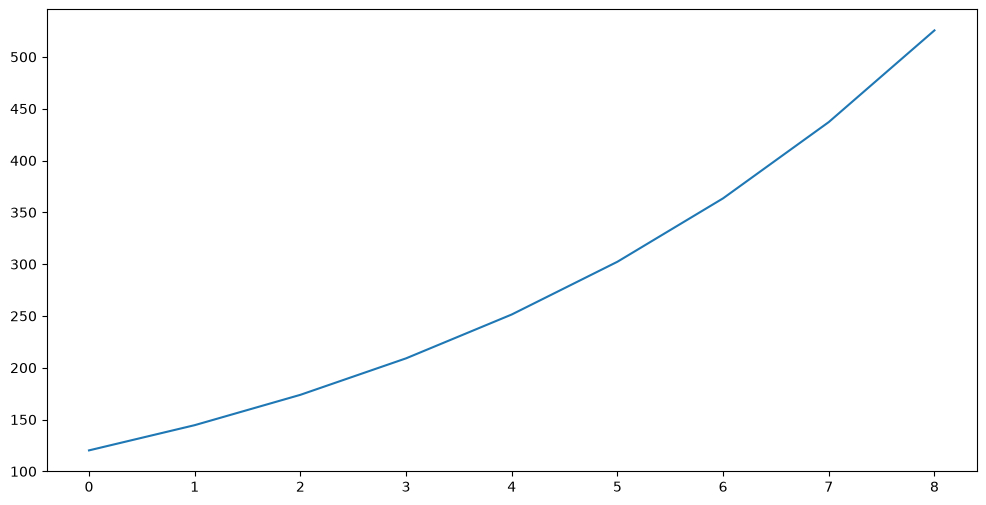

In [114]:
fig, ax = plt.subplots(figsize=(12, 6))

# ax.plot(c_otm2)
ax.plot(c_otm2)

